# Import Library

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import LSTM, Dropout, Dense, Input, GRU
from tensorflow.keras.models import Sequential
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Data Scraping

In [2]:
# List ticker untuk saham 10 perusahaan Indonesia
tickers = ['BBCA.JK', 'BYAN.JK', 'TPIA.JK', 'BBRI.JK', 'BMRI.JK', 'DSSA.JK', 'TLKM.JK', 'ASII.JK', 'BBNI.JK', 'ICBP.JK']

# Download data harga penutupan (adjusted close) untuk setiap perusahaan dengan interval 1 hari
stock_close_datas = {}
stock_open_datas = {}
stock_high_datas = {}
stock_low_datas = {}
stock_volume_datas = {}
for ticker in tickers:
  df = yf.download(ticker, start='2018-01-01', end='2025-05-28', interval='1d')
  stock_open_datas[ticker] = df['Open']
  stock_high_datas[ticker] = df['High']
  stock_low_datas[ticker] = df['Low']
  stock_volume_datas[ticker] = df['Volume']
  stock_close_datas[ticker] = df['Close']

# Gabung semua jadi 1 dataframe
df_all = pd.concat(stock_close_datas, axis=1)
df_all.columns = tickers

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
df_all

,BBCA.JK,BYAN.JK,TPIA.JK,BBRI.JK,BMRI.JK,DSSA.JK,TLKM.JK,ASII.JK,BBNI.JK,ICBP.JK
Date,,,,,,,,,,
2018-01-01,3723.926758,716.897888,1457.917480,2289.992920,2592.610107,1390.0,3339.208496,5383.928223,3732.603760,7525.143066
2018-01-02,3723.926758,723.661255,1439.693848,2283.701416,2543.998779,1410.0,3316.646484,5319.062500,3685.475342,7694.247559
2018-01-03,3723.926758,723.661255,1403.245605,2271.119141,2495.387207,1390.0,3181.273193,5221.761719,3553.513916,7694.247559
2018-01-04,3779.189453,716.897888,1348.573853,2233.372070,2535.896973,1390.0,3173.752197,5335.278809,3544.089111,7715.385254
2018-01-05,3783.441162,720.279541,1385.021729,2258.536865,2535.896973,1390.0,3218.876953,5383.928223,3506.385010,7842.214844
...,...,...,...,...,...,...,...,...,...,...
2025-05-21,9700.000000,19950.000000,9500.000000,4260.000000,5450.000000,50825.0,2750.000000,4670.000000,4520.000000,10825.000000
2025-05-22,9650.000000,19950.000000,9525.000000,4300.000000,5450.000000,51800.0,2800.000000,4630.000000,4470.000000,10800.000000
2025-05-23,9675.000000,19975.000000,10550.000000,4350.000000,5425.000000,52700.0,2690.000000,4740.000000,4510.000000,10825.000000


# Data Preprocessing

## Menangani Missing Value

In [4]:
df_all.isnull().sum()

BBCA.JK    0
BYAN.JK    0
TPIA.JK    0
BBRI.JK    0
BMRI.JK    0
DSSA.JK    0
TLKM.JK    1
ASII.JK    1
BBNI.JK    0
ICBP.JK    1
dtype: int64

In [5]:
# Melihat baris yang bernilai null
df_all[df_all.isnull().any(axis=1)]

,BBCA.JK,BYAN.JK,TPIA.JK,BBRI.JK,BMRI.JK,DSSA.JK,TLKM.JK,ASII.JK,BBNI.JK,ICBP.JK
Date,,,,,,,,,,
2019-06-19,5152.052246,1153.150635,1209.519653,2880.276123,2881.316895,1450.0,NaN,NaN,3534.166504,NaN


Melakukan Forward fill untuk mengisi data yang hilang pada `TLKM.JK`, `ASII.JK`, dan `ICBP.JK`

In [6]:
df_all_ffil = df_all.ffill()
display(df_all_ffil.loc["2019-06-18"])
display(df_all_ffil.loc["2019-06-19"])

BBCA.JK    5117.359863
BYAN.JK    1160.313110
TPIA.JK    1202.114380
BBRI.JK    2860.134521
BMRI.JK    2836.155029
DSSA.JK    1450.000000
TLKM.JK    3145.500732
ASII.JK    5101.784180
BBNI.JK    3464.675049
ICBP.JK    9077.743164
Name: 2019-06-18 00:00:00, dtype: float64

BBCA.JK    5152.052246
BYAN.JK    1153.150635
TPIA.JK    1209.519653
BBRI.JK    2880.276123
BMRI.JK    2881.316895
DSSA.JK    1450.000000
TLKM.JK    3145.500732
ASII.JK    5101.784180
BBNI.JK    3534.166504
ICBP.JK    9077.743164
Name: 2019-06-19 00:00:00, dtype: float64

In [7]:
df_all_ffil.shape

(1820, 10)

In [8]:
df_all_ffil.isnull().sum()

BBCA.JK    0
BYAN.JK    0
TPIA.JK    0
BBRI.JK    0
BMRI.JK    0
DSSA.JK    0
TLKM.JK    0
ASII.JK    0
BBNI.JK    0
ICBP.JK    0
dtype: int64

## Menangani Tanggal yang Terlewat dengan Forward Fill

Dilakukan Pengecekan terhadap berapa banyak hari yang tidak terdapat dalam data

In [9]:
full_date_range = pd.date_range(start=df_all_ffil.index.min(), end=df_all_ffil.index.max(), freq='D')
df_all_ffil.index = pd.to_datetime(df_all_ffil.index)

existing_dates = df_all_ffil.index.unique()

existing_dates_index = pd.DatetimeIndex(existing_dates)

missing_dates = full_date_range.difference(existing_dates_index)
print(f"Jumlah tanggal yang hilang: {missing_dates.size}")

Jumlah tanggal yang hilang: 884


Melakukan Forward Fill untuk mengisi tanggal yang hilang dengan cara menyebarkan data nilai terakhir yang diketahui ke depan hingga nilai berikutnya yang tidak hilang

In [10]:
df_all_ffil = df_all_ffil.reindex(full_date_range).ffill()
df_all_ffil.index.name = 'Date'
df_all_ffil

,BBCA.JK,BYAN.JK,TPIA.JK,BBRI.JK,BMRI.JK,DSSA.JK,TLKM.JK,ASII.JK,BBNI.JK,ICBP.JK
Date,,,,,,,,,,
2018-01-01,3723.926758,716.897888,1457.917480,2289.992920,2592.610107,1390.0,3339.208496,5383.928223,3732.603760,7525.143066
2018-01-02,3723.926758,723.661255,1439.693848,2283.701416,2543.998779,1410.0,3316.646484,5319.062500,3685.475342,7694.247559
2018-01-03,3723.926758,723.661255,1403.245605,2271.119141,2495.387207,1390.0,3181.273193,5221.761719,3553.513916,7694.247559
2018-01-04,3779.189453,716.897888,1348.573853,2233.372070,2535.896973,1390.0,3173.752197,5335.278809,3544.089111,7715.385254
2018-01-05,3783.441162,720.279541,1385.021729,2258.536865,2535.896973,1390.0,3218.876953,5383.928223,3506.385010,7842.214844
...,...,...,...,...,...,...,...,...,...,...
2025-05-23,9675.000000,19975.000000,10550.000000,4350.000000,5425.000000,52700.0,2690.000000,4740.000000,4510.000000,10825.000000
2025-05-24,9675.000000,19975.000000,10550.000000,4350.000000,5425.000000,52700.0,2690.000000,4740.000000,4510.000000,10825.000000
2025-05-25,9675.000000,19975.000000,10550.000000,4350.000000,5425.000000,52700.0,2690.000000,4740.000000,4510.000000,10825.000000


Melakukan pengecekan apakah tanggal yang hilang sudah berhasil diisi semuanya

In [11]:
full_date_range = pd.date_range(start=df_all_ffil.index.min(), end=df_all_ffil.index.max(), freq='D')
df_all_ffil.index = pd.to_datetime(df_all_ffil.index)

existing_dates = df_all_ffil.index.unique()

existing_dates_index = pd.DatetimeIndex(existing_dates)

missing_dates = full_date_range.difference(existing_dates_index)
print(f"Jumlah tanggal yang hilang: {missing_dates.size}")

Jumlah tanggal yang hilang: 0


## Mengganti Nama Kolom

In [12]:
df_all_ffil.columns = df_all_ffil.columns.str.replace('.JK', '', regex=False)
df_all_ffil

,BBCA,BYAN,TPIA,BBRI,BMRI,DSSA,TLKM,ASII,BBNI,ICBP
Date,,,,,,,,,,
2018-01-01,3723.926758,716.897888,1457.917480,2289.992920,2592.610107,1390.0,3339.208496,5383.928223,3732.603760,7525.143066
2018-01-02,3723.926758,723.661255,1439.693848,2283.701416,2543.998779,1410.0,3316.646484,5319.062500,3685.475342,7694.247559
2018-01-03,3723.926758,723.661255,1403.245605,2271.119141,2495.387207,1390.0,3181.273193,5221.761719,3553.513916,7694.247559
2018-01-04,3779.189453,716.897888,1348.573853,2233.372070,2535.896973,1390.0,3173.752197,5335.278809,3544.089111,7715.385254
2018-01-05,3783.441162,720.279541,1385.021729,2258.536865,2535.896973,1390.0,3218.876953,5383.928223,3506.385010,7842.214844
...,...,...,...,...,...,...,...,...,...,...
2025-05-23,9675.000000,19975.000000,10550.000000,4350.000000,5425.000000,52700.0,2690.000000,4740.000000,4510.000000,10825.000000
2025-05-24,9675.000000,19975.000000,10550.000000,4350.000000,5425.000000,52700.0,2690.000000,4740.000000,4510.000000,10825.000000
2025-05-25,9675.000000,19975.000000,10550.000000,4350.000000,5425.000000,52700.0,2690.000000,4740.000000,4510.000000,10825.000000


## Menambah Fitur Tanggal

Dilakukan pengubahan data tanggal dari index menjadi kolom date

In [13]:
df_all_ffil = df_all_ffil.reset_index()
df_all_ffil

,Date,BBCA,BYAN,TPIA,BBRI,BMRI,DSSA,TLKM,ASII,BBNI,ICBP
0,2018-01-01,3723.926758,716.897888,1457.917480,2289.992920,2592.610107,1390.0,3339.208496,5383.928223,3732.603760,7525.143066
1,2018-01-02,3723.926758,723.661255,1439.693848,2283.701416,2543.998779,1410.0,3316.646484,5319.062500,3685.475342,7694.247559
2,2018-01-03,3723.926758,723.661255,1403.245605,2271.119141,2495.387207,1390.0,3181.273193,5221.761719,3553.513916,7694.247559
3,2018-01-04,3779.189453,716.897888,1348.573853,2233.372070,2535.896973,1390.0,3173.752197,5335.278809,3544.089111,7715.385254
4,2018-01-05,3783.441162,720.279541,1385.021729,2258.536865,2535.896973,1390.0,3218.876953,5383.928223,3506.385010,7842.214844
...,...,...,...,...,...,...,...,...,...,...,...
2699,2025-05-23,9675.000000,19975.000000,10550.000000,4350.000000,5425.000000,52700.0,2690.000000,4740.000000,4510.000000,10825.000000
2700,2025-05-24,9675.000000,19975.000000,10550.000000,4350.000000,5425.000000,52700.0,2690.000000,4740.000000,4510.000000,10825.000000
2701,2025-05-25,9675.000000,19975.000000,10550.000000,4350.000000,5425.000000,52700.0,2690.000000,4740.000000,4510.000000,10825.000000
2702,2025-05-26,9625.000000,19975.000000,9750.000000,4320.000000,5475.000000,53900.0,2800.000000,4730.000000,4500.000000,11025.000000


## Menangani Duplikasi Data

In [14]:
print("Jumlah duplikasi data:", df_all_ffil.duplicated().sum())

Jumlah duplikasi data: 0


## Mengurutkan data

Karena data yang dibutuhkan merupakan data time series, maka datanya harus berurutan berdasarkan waktu (Kolom `Date`)

In [15]:
df_all_ffil = df_all_ffil.sort_values(by="Date", ascending=True)
df_all_ffil

,Date,BBCA,BYAN,TPIA,BBRI,BMRI,DSSA,TLKM,ASII,BBNI,ICBP
0,2018-01-01,3723.926758,716.897888,1457.917480,2289.992920,2592.610107,1390.0,3339.208496,5383.928223,3732.603760,7525.143066
1,2018-01-02,3723.926758,723.661255,1439.693848,2283.701416,2543.998779,1410.0,3316.646484,5319.062500,3685.475342,7694.247559
2,2018-01-03,3723.926758,723.661255,1403.245605,2271.119141,2495.387207,1390.0,3181.273193,5221.761719,3553.513916,7694.247559
3,2018-01-04,3779.189453,716.897888,1348.573853,2233.372070,2535.896973,1390.0,3173.752197,5335.278809,3544.089111,7715.385254
4,2018-01-05,3783.441162,720.279541,1385.021729,2258.536865,2535.896973,1390.0,3218.876953,5383.928223,3506.385010,7842.214844
...,...,...,...,...,...,...,...,...,...,...,...
2699,2025-05-23,9675.000000,19975.000000,10550.000000,4350.000000,5425.000000,52700.0,2690.000000,4740.000000,4510.000000,10825.000000
2700,2025-05-24,9675.000000,19975.000000,10550.000000,4350.000000,5425.000000,52700.0,2690.000000,4740.000000,4510.000000,10825.000000
2701,2025-05-25,9675.000000,19975.000000,10550.000000,4350.000000,5425.000000,52700.0,2690.000000,4740.000000,4510.000000,10825.000000
2702,2025-05-26,9625.000000,19975.000000,9750.000000,4320.000000,5475.000000,53900.0,2800.000000,4730.000000,4500.000000,11025.000000


# Data Exploration

## Deskripsi Variabel

Setiap kolom berisi harga saham penutupan (adjusted close) dari top 20 emiten Indonesia

In [16]:
df_all_ffil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2704 non-null   datetime64[ns]
 1   BBCA    2704 non-null   float64       
 2   BYAN    2704 non-null   float64       
 3   TPIA    2704 non-null   float64       
 4   BBRI    2704 non-null   float64       
 5   BMRI    2704 non-null   float64       
 6   DSSA    2704 non-null   float64       
 7   TLKM    2704 non-null   float64       
 8   ASII    2704 non-null   float64       
 9   BBNI    2704 non-null   float64       
 10  ICBP    2704 non-null   float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 232.5 KB


Terdapat nilai null pada beberapa kolom

In [17]:
df_all_ffil.describe()

,Date,BBCA,BYAN,TPIA,BBRI,BMRI,DSSA,TLKM,ASII,BBNI,ICBP
count,2704,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000,2704.000000
mean,2021-09-13 12:00:00,6647.044846,7508.757347,3075.294012,3323.686686,3496.613422,7859.921413,3132.537166,4521.508743,3383.968297,9258.538801
min,2018-01-01 00:00:00,3529.552734,591.778931,1093.920776,1513.757324,1411.886963,920.000000,2070.656250,2251.151855,1292.781372,6683.181152
25%,2019-11-07 18:00:00,5111.656250,1164.566650,1722.659424,2546.369019,2476.076172,1497.500000,2773.035339,4184.782593,2789.608887,8028.595703
50%,2021-09-13 12:00:00,6205.837646,1432.485352,2247.613770,3233.821167,2806.314453,2212.500000,3040.405029,4564.071777,3421.679932,9129.916016
75%,2023-07-21 06:00:00,8451.990234,17800.613770,2599.425537,3979.260986,4483.701050,5000.000000,3534.067383,4890.241455,3988.644287,10396.153320
max,2025-05-27 00:00:00,10570.414062,22548.173828,10625.000000,5763.100098,6769.004883,53900.000000,4295.701172,5738.723145,5460.848145,12800.000000
std,NaN,1897.875958,8006.582763,2358.763384,936.935336,1349.876990,12444.669658,469.313227,633.273784,899.857009,1393.909431


## Analisis Harga Saham Tiap Perusahaan

In [18]:
dates = df_all_ffil['Date']
stocks = df_all_ffil.drop(columns='Date')

<Figure size 1400x600 with 0 Axes>

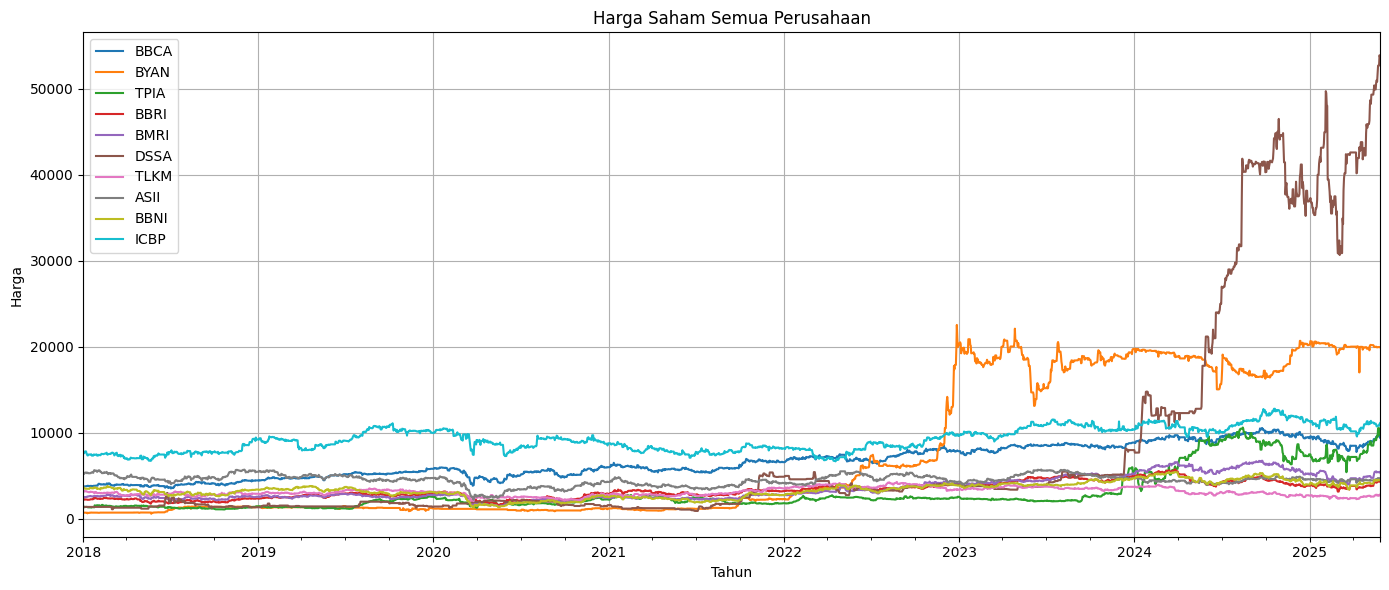

In [19]:
plt.figure(figsize=(14, 6))
stocks.index = dates  # ubah dates jadi index
stocks.plot(figsize=(14, 6))
plt.ylabel("Harga")
plt.xlabel("Tahun")
plt.title("Harga Saham Semua Perusahaan")
plt.grid(True)
plt.tight_layout()
plt.show()

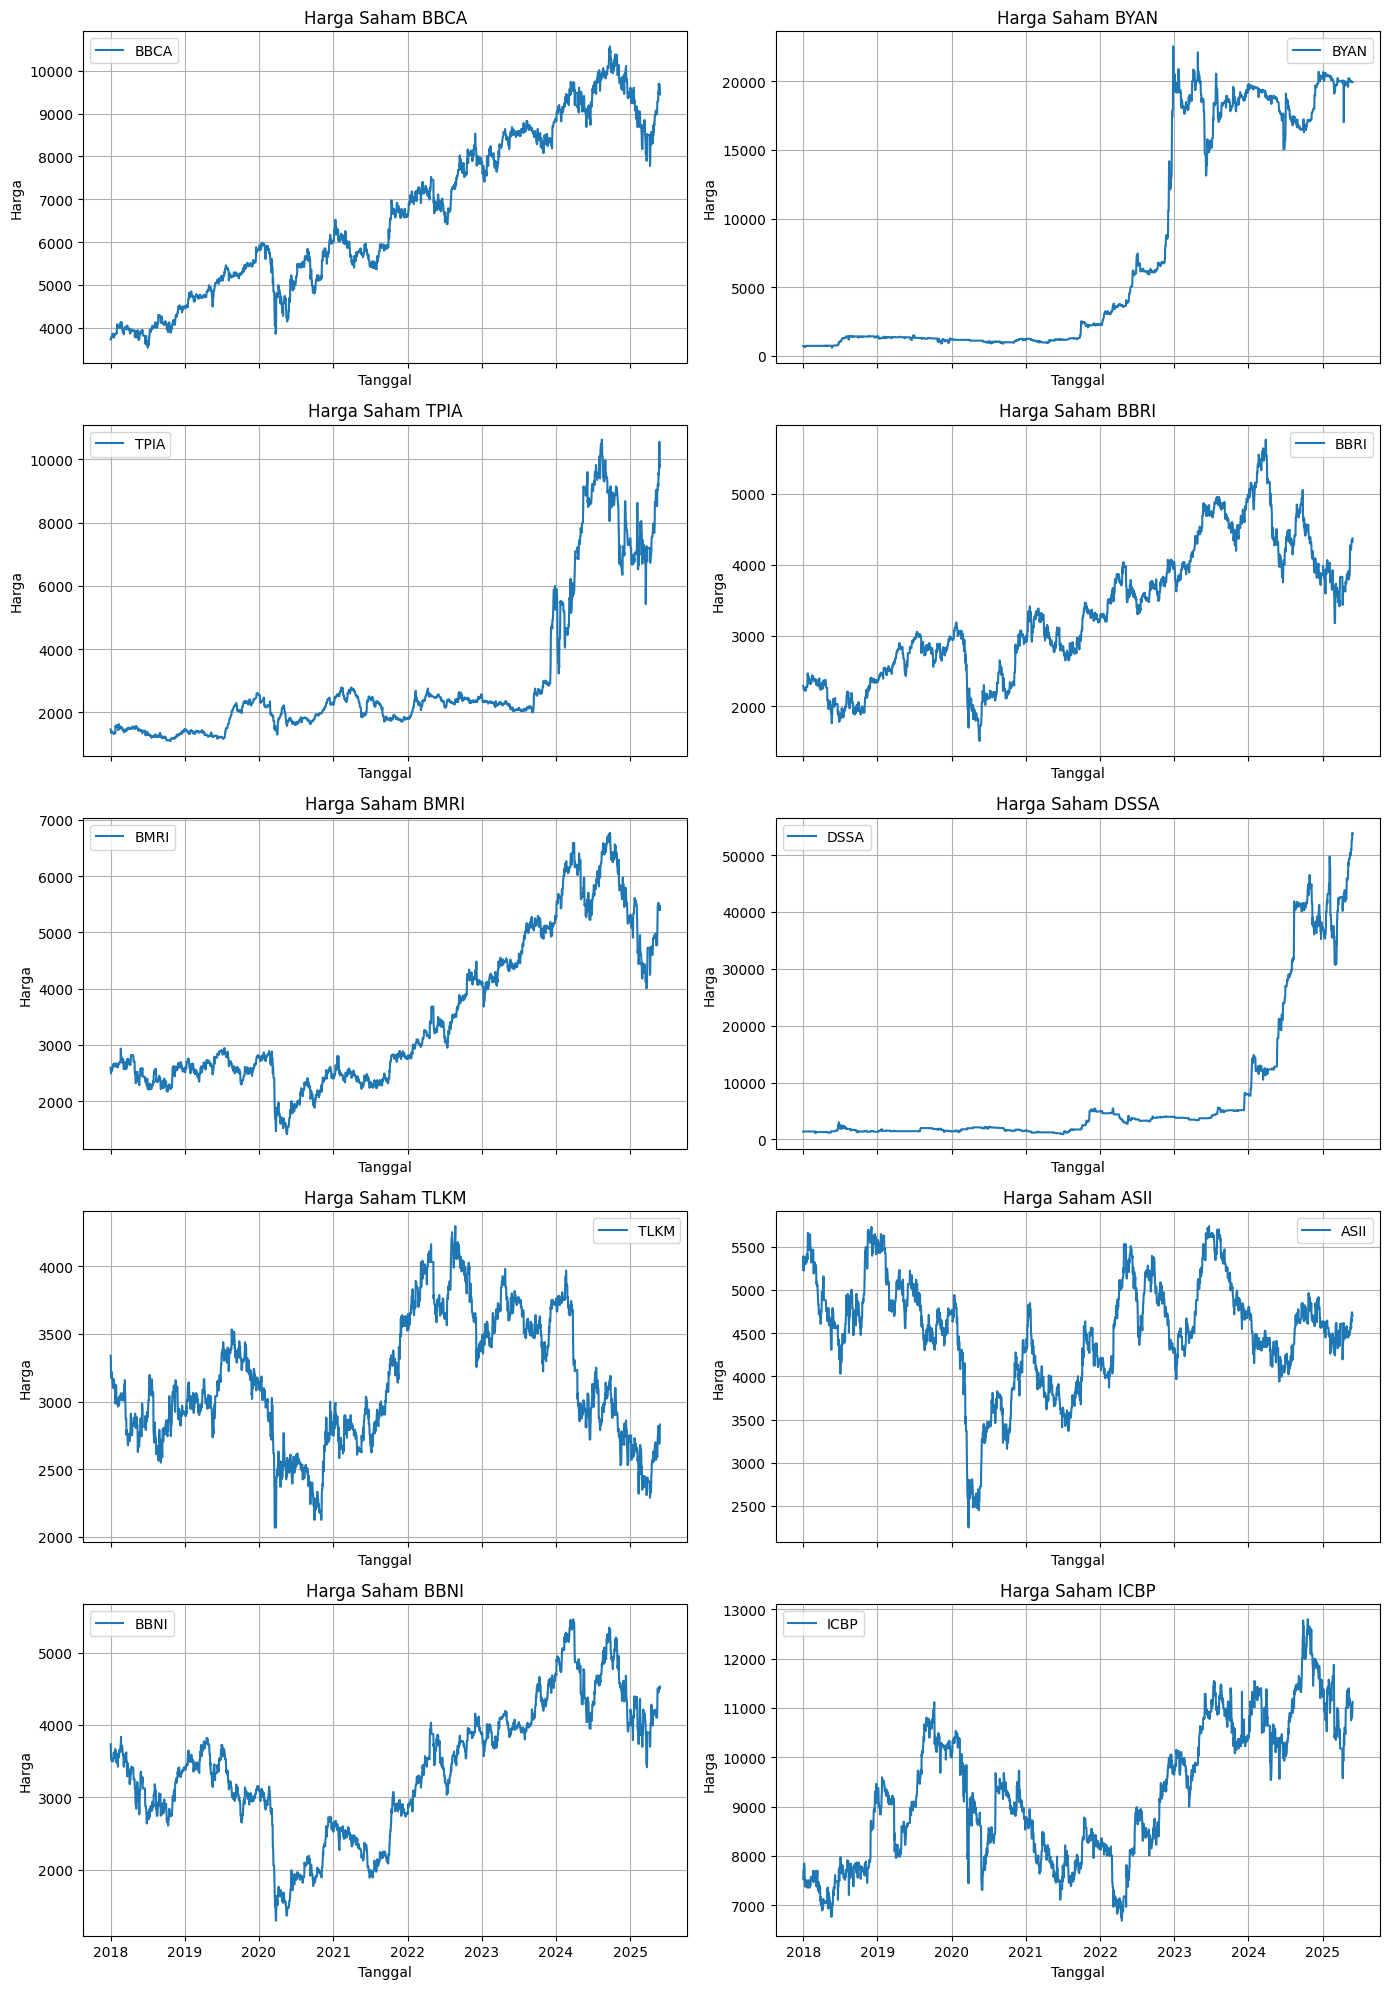

In [20]:
num_stocks = len(stocks.columns)
cols = 2  # jumlah kolom subplot
rows = (num_stocks + cols - 1) // cols  # jumlah baris yang dibutuhkan

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), sharex=True)
axes = axes.flatten()  # ubah axes jadi array datar agar mudah diakses

for i, stock in enumerate(stocks.columns):
    axes[i].plot(dates, stocks[stock], label=stock)
    axes[i].set_title(f"Harga Saham {stock}")
    axes[i].set_ylabel("Harga")
    axes[i].set_xlabel("Tanggal")
    axes[i].legend()
    axes[i].grid(True)

# Sembunyikan subplot kosong jika jumlah saham ganjil
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Korelasi Antar Saham

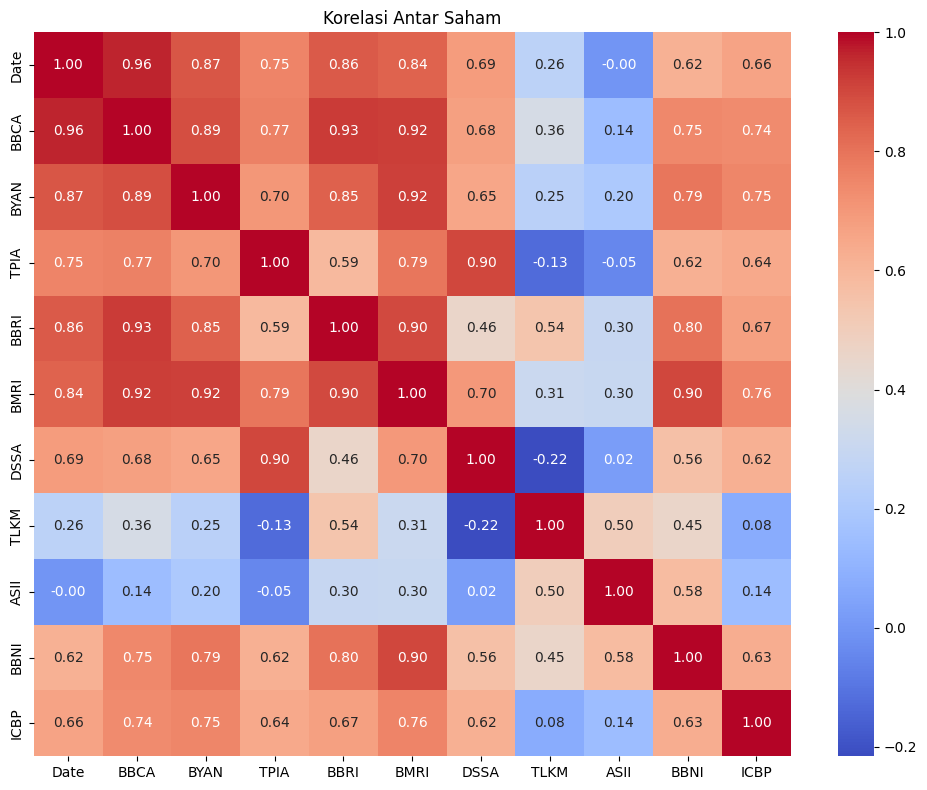

In [21]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_all_ffil.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasi Antar Saham")
plt.tight_layout()
plt.show()

# Data Preparation

## Simpan Data ke Format CSV

In [22]:
# Saving data to csv
df_all_ffil.to_csv("stocks.csv", index=False)

## Standarisasi Data

In [23]:
# Asumsikan df_all_ffil sudah tersedia
df = df_all_ffil.copy()
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Simpan nama saham
tickers = df.columns.tolist()

# Simpan hasil standarisasi
scalers = {ticker: StandardScaler() for ticker in tickers}
df_scaled = pd.DataFrame(index=df.index)

# Standarisasi per kolom
for ticker in tickers:
    df_scaled[ticker] = scalers[ticker].fit_transform(df[[ticker]])

## Windowing

In [24]:
def create_sliding_window(data, window_size=30, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size + horizon - 1])
    return np.array(X), np.array(y)

## Splitting Data

In [25]:
# Split rasio: 70% train, 15% eval, 15% test
train_ratio = 0.7
eval_ratio = 0.15

def split_data(data, window_size, horizon):
    X, y = create_sliding_window(data, window_size, horizon)
    n = len(X)
    train_end = int(n * train_ratio)
    eval_end = train_end + int(n * eval_ratio)

    return (X[:train_end], y[:train_end],
            X[train_end:eval_end], y[train_end:eval_end],
            X[eval_end:], y[eval_end:])

# Modeling

## BBCA

In [26]:
window_size = 30
horizon = 1

data_bbca = df_scaled['BBCA'].values
X_train_bbca, y_train_bbca, X_val_bbca, y_val_bbca, X_test_bbca, y_test_bbca = split_data(data_bbca, window_size, horizon)

model_bbca = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dense(1)
])

model_bbca.compile(optimizer='adam', loss='mae', metrics=['mape'])

model_bbca.summary()
print("Model input shape:", model_bbca.input_shape)
print("Model output shape:", model_bbca.output_shape)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,033 (453.25 KB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

Model input shape: (None, 30, 1)
Model output shape: (None, 1)


In [27]:
history_bbca = model_bbca.fit(X_train_bbca[..., np.newaxis], y_train_bbca,
              validation_data=(X_val_bbca[..., np.newaxis], y_val_bbca),
              epochs=40)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.2336 - mape: 63.7560 - val_loss: 0.1272 - val_mape: 11.1732
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0509 - mape: 28.9977 - val_loss: 0.1092 - val_mape: 9.7167
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0502 - mape: 32.4115 - val_loss: 0.0829 - val_mape: 7.3812
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0519 - mape: 27.9415 - val_loss: 0.0886 - val_mape: 7.8639
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0395 - mape: 29.4999 - val_loss: 0.0542 - val_mape: 4.8990
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0385 - mape: 22.1408 - val_loss: 0.0992 - val_mape: 8.8700
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0398 - mape: 23.4452 - val_loss: 0.0444 - val_mape: 4.2010
Epoch 8/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0370 - mape: 25.7292 - val_loss: 0.0527 - val_mape: 4.7467
Epoch 9/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2

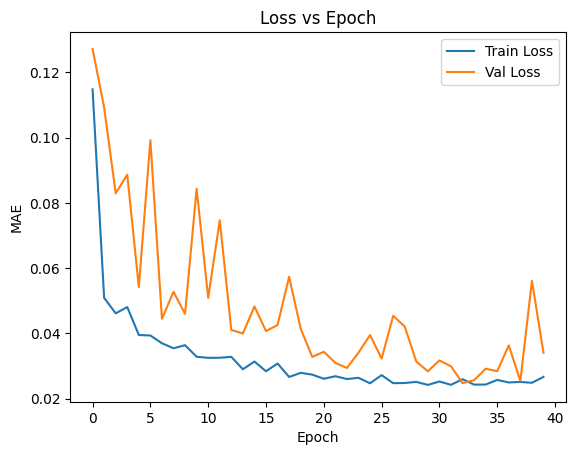

In [28]:
plt.plot(history_bbca.history['loss'], label='Train Loss')
plt.plot(history_bbca.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [29]:
y_pred_bbca = model_bbca.predict(X_test_bbca[..., np.newaxis]).flatten()
scaler_bbca = scalers['BBCA']
y_pred_unscaled_bbca = scaler_bbca.inverse_transform(y_pred_bbca.reshape(-1, 1)).flatten()
y_test_unscaled_bbca = scaler_bbca.inverse_transform(y_test_bbca.reshape(-1, 1)).flatten()

mae_bbca = mean_absolute_error(y_test_unscaled_bbca, y_pred_unscaled_bbca)
rmse_bbca = np.sqrt(mean_squared_error(y_test_unscaled_bbca, y_pred_unscaled_bbca))
mape_bbca = mean_absolute_percentage_error(y_test_unscaled_bbca, y_pred_unscaled_bbca) * 100

print('MAE Data Test BBCA : ', mae_bbca)
print('RMSE Data Test BBCA: ', rmse_bbca)
print('MAPE Data Test BBCA: ', mape_bbca)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
MAE Data Test BBCA :  112.84684487717662
RMSE Data Test BBCA:  146.02373810198318
MAPE Data Test BBCA:  1.199252868468922


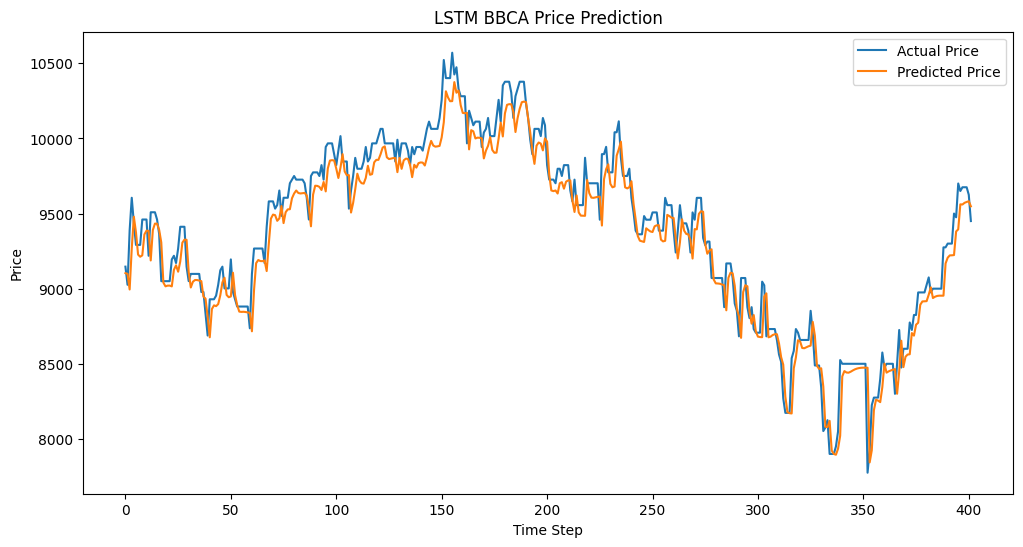

In [30]:
plt.figure(figsize=(12,6))
plt.plot(y_test_unscaled_bbca, label='Actual Price')
plt.plot(y_pred_unscaled_bbca, label='Predicted Price')
plt.title('LSTM BBCA Price Prediction')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.show()

In [31]:
time_span = {'1d': 1, '1w': 7, '1m': 30, '3m': 90, '6m': 180}
recent_data_bbca = data_bbca[-365:]

pred_dict_bbca = {}
for label, steps in time_span.items():
    X = recent_data_bbca.copy()
    for _ in range(steps):
        x_input = X[-365:].reshape(1, 365, 1)
        next_pred = model_bbca.predict(x_input, verbose=0)[0, 0]
        X = np.append(X, next_pred)

    # Ambil nilai terakhir dan kembalikan ke skala asli
    unscaled_pred_bbca = scaler_bbca.inverse_transform([[X[-1]]])[0, 0]
    pred_dict_bbca[label] = float(unscaled_pred_bbca)

pred_dict_bbca

{'1d': 9412.740863020812,
 '1w': 9194.030992480855,
 '1m': 8521.433491865791,
 '3m': 7837.590328710864,
 '6m': 7490.743241946034}

## BYAN

In [32]:
window_size = 30
horizon = 1

data_byan = df_scaled['BYAN'].values
X_train_byan, y_train_byan, X_val_byan, y_val_byan, X_test_byan, y_test_byan = split_data(data_byan, window_size, horizon)

model_byan = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1)
])

model_byan.compile(optimizer='adam', loss='mae', metrics=['mape'])

model_byan.summary()
print("Model input shape:", model_byan.input_shape)
print("Model output shape:", model_byan.output_shape)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Model input shape: (None, 30, 1)
Model output shape: (None, 1)


In [33]:
history_byan = model_byan.fit(X_train_byan[..., np.newaxis], y_train_byan,
              validation_data=(X_val_byan[..., np.newaxis], y_val_byan),
              epochs=40)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.2551 - mape: 40.7389 - val_loss: 0.0980 - val_mape: 8.1228
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0207 - mape: 7.1554 - val_loss: 0.0630 - val_mape: 5.1871
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0217 - mape: 7.2308 - val_loss: 0.0916 - val_mape: 6.8528
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0192 - mape: 7.8363 - val_loss: 0.0618 - val_mape: 4.8843
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0214 - mape: 5.6438 - val_loss: 0.0635 - val_mape: 5.2270
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0177 - mape: 5.5744 - val_loss: 0.0632 - val_mape: 4.8959
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0169 - mape: 6.0631 - val_loss: 0.0522 - val_mape: 4.1644
Epoch 8/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0160 - mape: 7.8784 - val_loss: 0.0496 - val_mape: 4.0480
Epoch 9/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/s

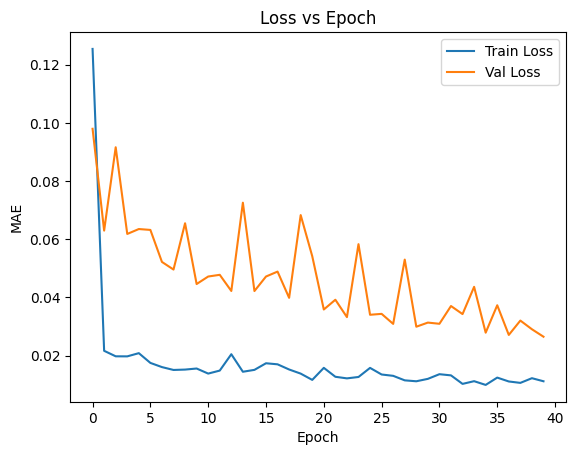

In [34]:
plt.plot(history_byan.history['loss'], label='Train Loss')
plt.plot(history_byan.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [35]:
y_pred_byan = model_byan.predict(X_test_byan[..., np.newaxis]).flatten()
scaler_byan = scalers['BYAN']
y_pred_unscaled_byan = scaler_byan.inverse_transform(y_pred_byan.reshape(-1, 1)).flatten()
y_test_unscaled_byan = scaler_byan.inverse_transform(y_test_byan.reshape(-1, 1)).flatten()

mae_byan = mean_absolute_error(y_test_unscaled_byan, y_pred_unscaled_byan)
rmse_byan = np.sqrt(mean_squared_error(y_test_unscaled_byan, y_pred_unscaled_byan))
mape_byan = mean_absolute_percentage_error(y_test_unscaled_byan, y_pred_unscaled_byan) * 100

print('MAE Data Test BYAN : ', mae_byan)
print('RMSE Data Test BYAN: ', rmse_byan)
print('MAPE Data Test BYAN: ', mape_byan)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
MAE Data Test BYAN :  216.34022028529228
RMSE Data Test BYAN:  345.9732951010673
MAPE Data Test BYAN:  1.170701291142719


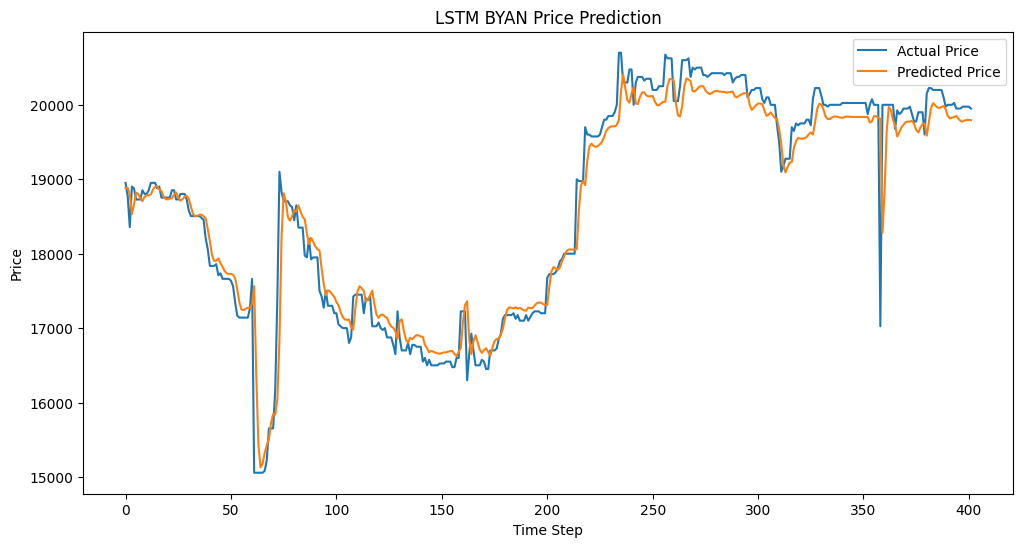

In [36]:
plt.figure(figsize=(12,6))
plt.plot(y_test_unscaled_byan, label='Actual Price')
plt.plot(y_pred_unscaled_byan, label='Predicted Price')
plt.title('LSTM BYAN Price Prediction')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.show()

In [37]:
time_span = {'1d': 1, '1w': 7, '1m': 30, '3m': 90, '6m': 180}
recent_data_byan = data_byan[-365:]

pred_dict_byan = {}
for label, steps in time_span.items():
    X = recent_data_byan.copy()
    for _ in range(steps):
        x_input = X[-365:].reshape(1, 365, 1)
        next_pred = model_byan.predict(x_input, verbose=0)[0, 0]
        X = np.append(X, next_pred)

    # Ambil nilai terakhir dan kembalikan ke skala asli
    unscaled_pred_byan = scaler_byan.inverse_transform([[X[-1]]])[0, 0]
    pred_dict_byan[label] = float(unscaled_pred_byan)

pred_dict_byan

{'1d': 19774.93616208881,
 '1w': 19284.95406808923,
 '1m': 18574.933506851135,
 '3m': 18516.31097635877,
 '6m': 18517.354007171038}

## TPIA

In [38]:
window_size = 30
horizon = 1

data_tpia = df_scaled['TPIA'].values
X_train_tpia, y_train_tpia, X_val_tpia, y_val_tpia, X_test_tpia, y_test_tpia = split_data(data_tpia, window_size, horizon)

model_tpia = Sequential([
    Input(shape=(window_size, 1)),
    GRU(128, return_sequences=True),
    Dropout(0.2),
    GRU(64),
    Dropout(0.2),
    Dense(1)
])

model_tpia.compile(optimizer='adam', loss='mae', metrics=['mape'])

model_tpia.summary()
print("Model input shape:", model_tpia.input_shape)
print("Model output shape:", model_tpia.output_shape)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 128)        │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,617 (342.25 KB)

 Trainable params: 87,617 (342.25 KB)

 Non-trainable params: 0 (0.00 B)

Model input shape: (None, 30, 1)
Model output shape: (None, 1)


In [39]:
history_tpia = model_tpia.fit(X_train_tpia[..., np.newaxis], y_train_tpia,
              validation_data=(X_val_tpia[..., np.newaxis], y_val_tpia),
              epochs=40)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.1583 - mape: 33.0847 - val_loss: 0.0599 - val_mape: 16.0488
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0383 - mape: 8.5999 - val_loss: 0.0827 - val_mape: 17.9683
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0383 - mape: 8.4747 - val_loss: 0.0547 - val_mape: 14.0902
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0328 - mape: 7.2540 - val_loss: 0.0656 - val_mape: 18.3154
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0351 - mape: 7.7091 - val_loss: 0.0598 - val_mape: 13.5929
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0315 - mape: 6.9609 - val_loss: 0.0488 - val_mape: 12.0800
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0314 - mape: 6.8878 - val_loss: 0.0640 - val_mape: 13.9228
Epoch 8/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0310 - mape: 6.8040 - val_loss: 0.0535 - val_mape: 12.3529
Epoch 9/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2

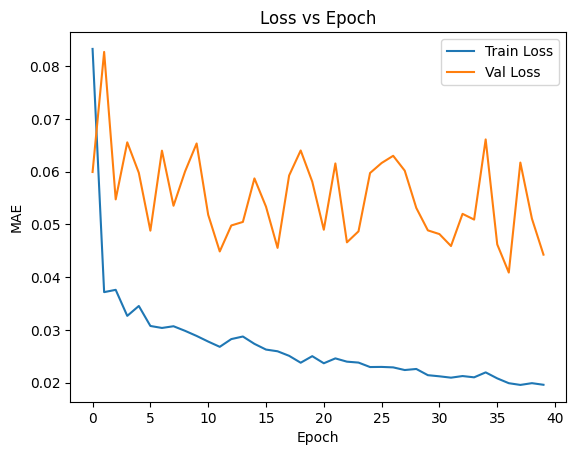

In [40]:
plt.plot(history_tpia.history['loss'], label='Train Loss')
plt.plot(history_tpia.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [41]:
y_pred_tpia = model_tpia.predict(X_test_tpia[..., np.newaxis]).flatten()
scaler_tpia = scalers['TPIA']
y_pred_unscaled_tpia = scaler_tpia.inverse_transform(y_pred_tpia.reshape(-1, 1)).flatten()
y_test_unscaled_tpia = scaler_tpia.inverse_transform(y_test_tpia.reshape(-1, 1)).flatten()

mae_tpia = mean_absolute_error(y_test_unscaled_tpia, y_pred_unscaled_tpia)
rmse_tpia = np.sqrt(mean_squared_error(y_test_unscaled_tpia, y_pred_unscaled_tpia))
mape_tpia = mean_absolute_percentage_error(y_test_unscaled_tpia, y_pred_unscaled_tpia) * 100

print('MAE Data Test TPIA : ', mae_tpia)
print('RMSE Data Test TPIA: ', rmse_tpia)
print('MAPE Data Test TPIA: ', mape_tpia)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
MAE Data Test TPIA :  676.7662250272077
RMSE Data Test TPIA:  770.472720316237
MAPE Data Test TPIA:  7.946934241360355


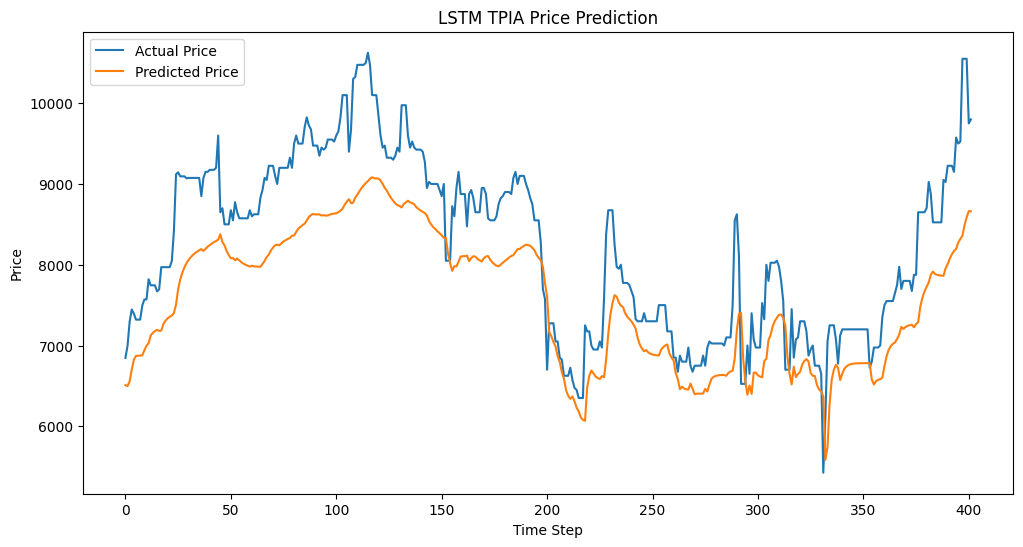

In [42]:
plt.figure(figsize=(12,6))
plt.plot(y_test_unscaled_tpia, label='Actual Price')
plt.plot(y_pred_unscaled_tpia, label='Predicted Price')
plt.title('LSTM TPIA Price Prediction')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.show()

In [43]:
time_span = {'1d': 1, '1w': 7, '1m': 30, '3m': 90, '6m': 180}
recent_data_tpia = data_tpia[-365:]

pred_dict_tpia = {}
for label, steps in time_span.items():
    X = recent_data_tpia.copy()
    for _ in range(steps):
        x_input = X[-365:].reshape(1, 365, 1)
        next_pred = model_tpia.predict(x_input, verbose=0)[0, 0]
        X = np.append(X, next_pred)

    # Ambil nilai terakhir dan kembalikan ke skala asli
    unscaled_pred_tpia = scaler_tpia.inverse_transform([[X[-1]]])[0, 0]
    pred_dict_tpia[label] = float(unscaled_pred_tpia)

pred_dict_tpia

{'1d': 8637.845562821767,
 '1w': 7889.166375718211,
 '1m': 4505.251372174271,
 '3m': 2918.210562824964,
 '6m': 2788.7244363621003}

## BBRI

In [44]:
window_size = 30
horizon = 1

data_bbri = df_scaled['BBRI'].values
X_train_bbri, y_train_bbri, X_val_bbri, y_val_bbri, X_test_bbri, y_test_bbri = split_data(data_bbri, window_size, horizon)

model_bbri = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1)
])

model_bbri.compile(optimizer='adam', loss='mae', metrics=['mape'])

model_bbri.summary()
print("Model input shape:", model_bbri.input_shape)
print("Model output shape:", model_bbri.output_shape)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Model input shape: (None, 30, 1)
Model output shape: (None, 1)


In [45]:
history_bbri = model_bbri.fit(X_train_bbri[..., np.newaxis], y_train_bbri,
              validation_data=(X_val_bbri[..., np.newaxis], y_val_bbri),
              epochs=40)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.3308 - mape: 109.8981 - val_loss: 0.5482 - val_mape: 32.9648
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0830 - mape: 60.4627 - val_loss: 0.3548 - val_mape: 20.9152
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0707 - mape: 52.9324 - val_loss: 0.2868 - val_mape: 16.6492
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0692 - mape: 37.6957 - val_loss: 0.2337 - val_mape: 13.3728
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0647 - mape: 51.8097 - val_loss: 0.2876 - val_mape: 17.0523
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0599 - mape: 36.9531 - val_loss: 0.2201 - val_mape: 12.8207
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0545 - mape: 47.1733 - val_loss: 0.1931 - val_mape: 11.1265
Epoch 8/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0557 - mape: 28.3059 - val_loss: 0.1943 - val_mape: 11.1672
Epoch 9/40
59/59 ━━━━━━━━━━━━━━

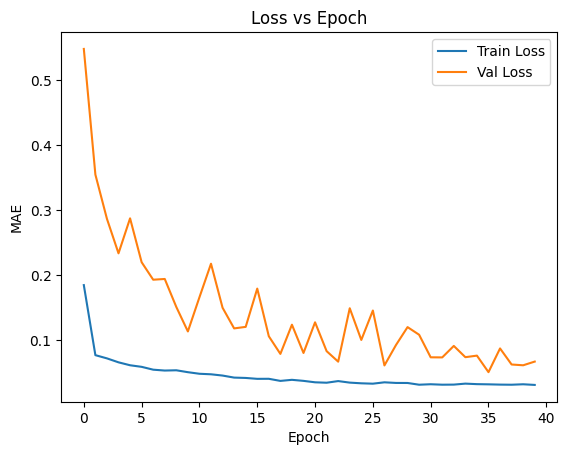

In [46]:
plt.plot(history_bbri.history['loss'], label='Train Loss')
plt.plot(history_bbri.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [47]:
y_pred_bbri = model_bbri.predict(X_test_bbri[..., np.newaxis]).flatten()
scaler_bbri = scalers['BBRI']
y_pred_unscaled_bbri = scaler_bbri.inverse_transform(y_pred_bbri.reshape(-1, 1)).flatten()
y_test_unscaled_bbri = scaler_bbri.inverse_transform(y_test_bbri.reshape(-1, 1)).flatten()

mae_bbri = mean_absolute_error(y_test_unscaled_bbri, y_pred_unscaled_bbri)
rmse_bbri = np.sqrt(mean_squared_error(y_test_unscaled_bbri, y_pred_unscaled_bbri))
mape_bbri = mean_absolute_percentage_error(y_test_unscaled_bbri, y_pred_unscaled_bbri) * 100

print('MAE Data Test BBRI : ', mae_bbri)
print('RMSE Data Test BBRI: ', rmse_bbri)
print('MAPE Data Test BBRI: ', mape_bbri)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
MAE Data Test BBRI :  48.1402150623834
RMSE Data Test BBRI:  73.77937778799867
MAPE Data Test BBRI:  1.182093040028132


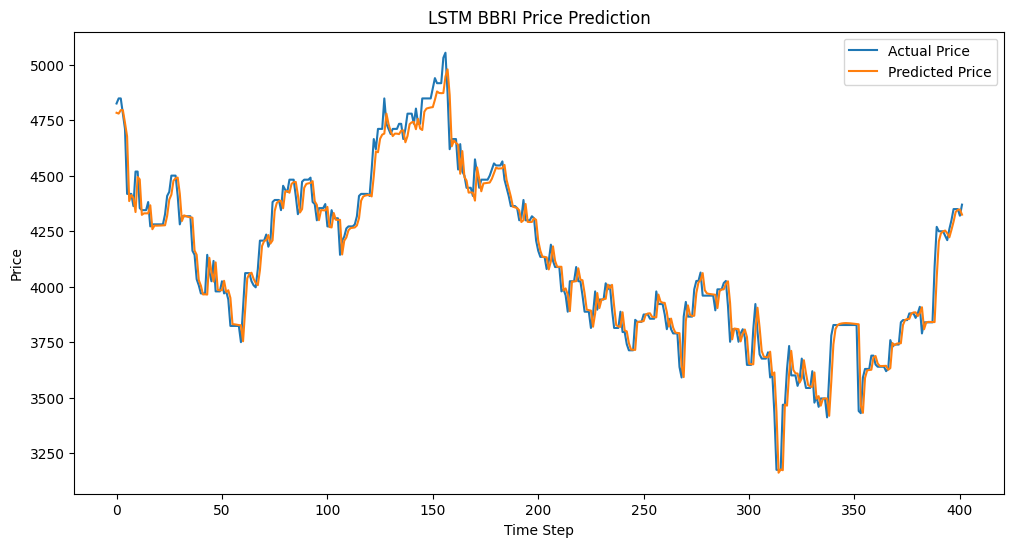

In [48]:
plt.figure(figsize=(12,6))
plt.plot(y_test_unscaled_bbri, label='Actual Price')
plt.plot(y_pred_unscaled_bbri, label='Predicted Price')
plt.title('LSTM BBRI Price Prediction')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.show()

In [49]:
time_span = {'1d': 1, '1w': 7, '1m': 30, '3m': 90, '6m': 180}
recent_data_bbri = data_bbri[-365:]

pred_dict_bbri = {}
for label, steps in time_span.items():
    X = recent_data_bbri.copy()
    for _ in range(steps):
        x_input = X[-365:].reshape(1, 365, 1)
        next_pred = model_bbri.predict(x_input, verbose=0)[0, 0]
        X = np.append(X, next_pred)

    # Ambil nilai terakhir dan kembalikan ke skala asli
    unscaled_pred_bbri = scaler_bbri.inverse_transform([[X[-1]]])[0, 0]
    pred_dict_bbri[label] = float(unscaled_pred_bbri)

pred_dict_bbri

{'1d': 4362.6213423024265,
 '1w': 4352.9421691632115,
 '1m': 4322.16336788254,
 '3m': 4373.353347186951,
 '6m': 4382.130779093309}

## BMRI

In [50]:
window_size = 30
horizon = 1

data_bmri = df_scaled['BMRI'].values
X_train_bmri, y_train_bmri, X_val_bmri, y_val_bmri, X_test_bmri, y_test_bmri = split_data(data_bmri, window_size, horizon)

model_bmri = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1)
])

model_bmri.compile(optimizer='adam', loss='mae', metrics=['mape'])

model_bmri.summary()
print("Model input shape:", model_bmri.input_shape)
print("Model output shape:", model_bmri.output_shape)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Model input shape: (None, 30, 1)
Model output shape: (None, 1)


In [51]:
history_bmri = model_bmri.fit(X_train_bmri[..., np.newaxis], y_train_bmri,
              validation_data=(X_val_bmri[..., np.newaxis], y_val_bmri),
              epochs=40)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.2032 - mape: 53.3825 - val_loss: 0.4351 - val_mape: 31.2453
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0532 - mape: 36.1776 - val_loss: 0.3386 - val_mape: 23.1516
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0496 - mape: 26.1222 - val_loss: 0.3324 - val_mape: 22.8583
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0466 - mape: 43.2373 - val_loss: 0.2851 - val_mape: 19.0003
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0449 - mape: 42.0815 - val_loss: 0.2842 - val_mape: 19.0376
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0397 - mape: 29.0590 - val_loss: 0.2976 - val_mape: 20.0714
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0390 - mape: 28.4661 - val_loss: 0.3015 - val_mape: 20.4142
Epoch 8/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0395 - mape: 23.3890 - val_loss: 0.2737 - val_mape: 18.3696
Epoch 9/40
59/59 ━━━━━━━━━━━━━━━

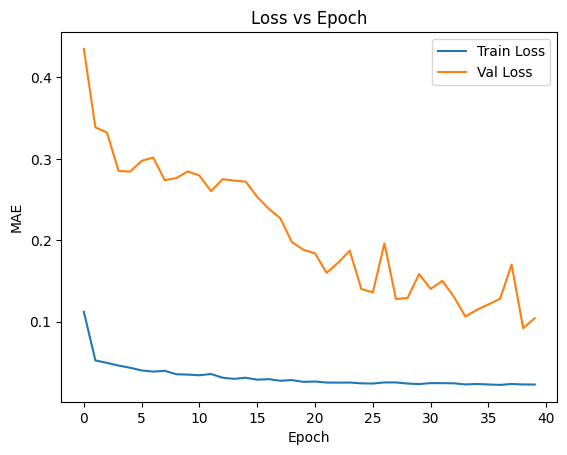

In [52]:
plt.plot(history_bmri.history['loss'], label='Train Loss')
plt.plot(history_bmri.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [53]:
y_pred_bmri = model_bmri.predict(X_test_bmri[..., np.newaxis]).flatten()
scaler_bmri = scalers['BMRI']
y_pred_unscaled_bmri = scaler_bmri.inverse_transform(y_pred_bmri.reshape(-1, 1)).flatten()
y_test_unscaled_bmri = scaler_bmri.inverse_transform(y_test_bmri.reshape(-1, 1)).flatten()

mae_bmri = mean_absolute_error(y_test_unscaled_bmri, y_pred_unscaled_bmri)
rmse_bmri = np.sqrt(mean_squared_error(y_test_unscaled_bmri, y_pred_unscaled_bmri))
mape_bmri = mean_absolute_percentage_error(y_test_unscaled_bmri, y_pred_unscaled_bmri) * 100

print('MAE Data Test BMRI : ', mae_bmri)
print('RMSE Data Test BMRI: ', rmse_bmri)
print('MAPE Data Test BMRI: ', mape_bmri)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
MAE Data Test BMRI :  231.30126285078515
RMSE Data Test BMRI:  290.37810446889017
MAPE Data Test BMRI:  3.9181516086272086


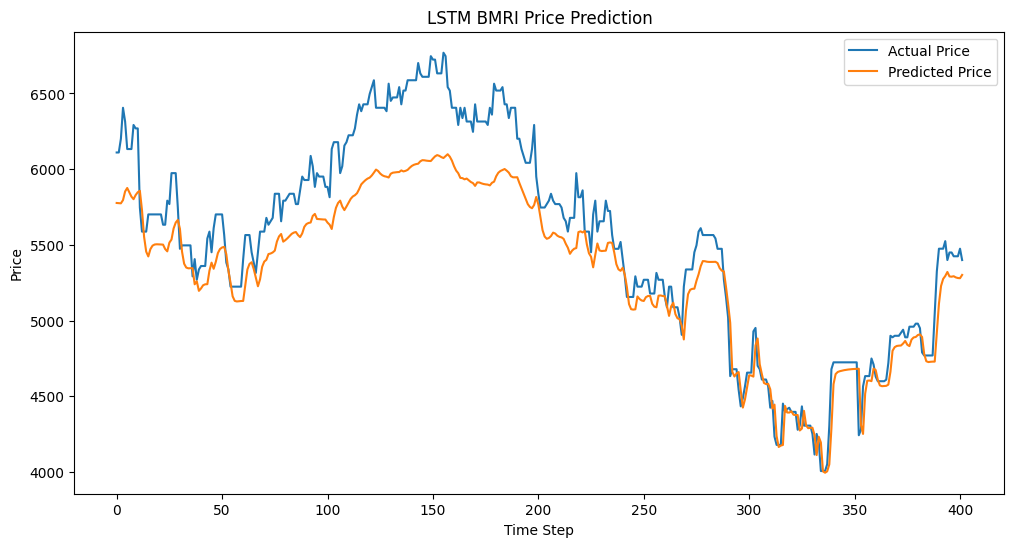

In [54]:
plt.figure(figsize=(12,6))
plt.plot(y_test_unscaled_bmri, label='Actual Price')
plt.plot(y_pred_unscaled_bmri, label='Predicted Price')
plt.title('LSTM BMRI Price Prediction')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.show()

In [55]:
time_span = {'1d': 1, '1w': 7, '1m': 30, '3m': 90, '6m': 180}
recent_data_bmri = data_bmri[-365:]

pred_dict_bmri = {}
for label, steps in time_span.items():
    X = recent_data_bmri.copy()
    for _ in range(steps):
        x_input = X[-365:].reshape(1, 365, 1)
        next_pred = model_bmri.predict(x_input, verbose=0)[0, 0]
        X = np.append(X, next_pred)

    # Ambil nilai terakhir dan kembalikan ke skala asli
    unscaled_pred_bmri = scaler_bmri.inverse_transform([[X[-1]]])[0, 0]
    pred_dict_bmri[label] = float(unscaled_pred_bmri)

pred_dict_bmri

{'1d': 5277.424640213882,
 '1w': 4887.957140117116,
 '1m': 4237.350445182494,
 '3m': 3885.242413138031,
 '6m': 3791.4098880840966}

## DSSA

In [56]:
window_size = 30
horizon = 1

data_dssa = df_scaled['DSSA'].values
X_train_dssa, y_train_dssa, X_val_dssa, y_val_dssa, X_test_dssa, y_test_dssa = split_data(data_dssa, window_size, horizon)

model_dssa = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

model_dssa.compile(optimizer='adam', loss='mae', metrics=['mape'])

model_dssa.summary()
print("Model input shape:", model_dssa.input_shape)
print("Model output shape:", model_dssa.output_shape)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,033 (453.25 KB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

Model input shape: (None, 30, 1)
Model output shape: (None, 1)


In [57]:
history_dssa = model_dssa.fit(X_train_dssa[..., np.newaxis], y_train_dssa,
              validation_data=(X_val_dssa[..., np.newaxis], y_val_dssa),
              epochs=40)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.1386 - mape: 30.8793 - val_loss: 0.0528 - val_mape: 100.9986
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0323 - mape: 7.3707 - val_loss: 0.0345 - val_mape: 70.5393
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0288 - mape: 6.4836 - val_loss: 0.0288 - val_mape: 64.0372
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0292 - mape: 6.7349 - val_loss: 0.0310 - val_mape: 68.0495
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0286 - mape: 6.4883 - val_loss: 0.0275 - val_mape: 60.7969
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0275 - mape: 6.3862 - val_loss: 0.0320 - val_mape: 67.8636
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0274 - mape: 6.2116 - val_loss: 0.0353 - val_mape: 70.3985
Epoch 8/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0251 - mape: 5.7770 - val_loss: 0.0254 - val_mape: 57.9240
Epoch 9/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 

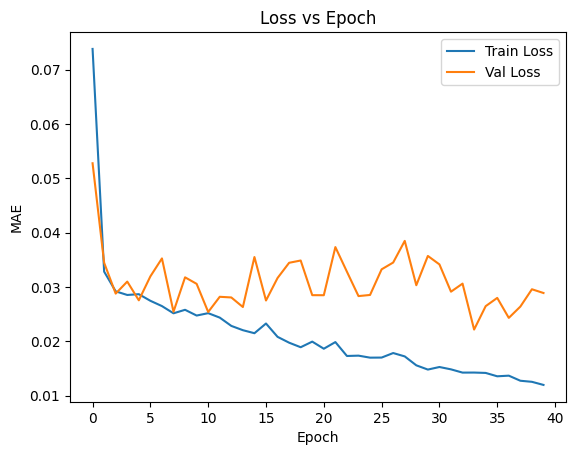

In [58]:
plt.plot(history_dssa.history['loss'], label='Train Loss')
plt.plot(history_dssa.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [59]:
y_pred_dssa = model_dssa.predict(X_test_dssa[..., np.newaxis]).flatten()
scaler_dssa = scalers['DSSA']
y_pred_unscaled_dssa = scaler_dssa.inverse_transform(y_pred_dssa.reshape(-1, 1)).flatten()
y_test_unscaled_dssa = scaler_dssa.inverse_transform(y_test_dssa.reshape(-1, 1)).flatten()

mae_dssa = mean_absolute_error(y_test_unscaled_dssa, y_pred_unscaled_dssa)
rmse_dssa = np.sqrt(mean_squared_error(y_test_unscaled_dssa, y_pred_unscaled_dssa))
mape_dssa = mean_absolute_percentage_error(y_test_unscaled_dssa, y_pred_unscaled_dssa) * 100

print('MAE Data Test DSSA : ', mae_dssa)
print('RMSE Data Test DSSA: ', rmse_dssa)
print('MAPE Data Test DSSA: ', mape_dssa)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
MAE Data Test DSSA :  2590.010108150653
RMSE Data Test DSSA:  3008.74306843854
MAPE Data Test DSSA:  7.6457780913618265


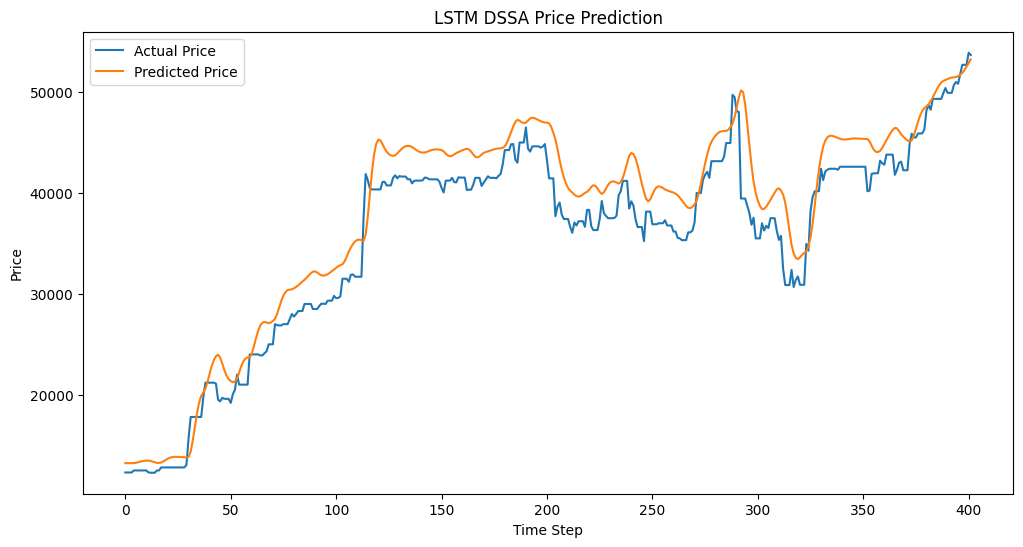

In [60]:
plt.figure(figsize=(12,6))
plt.plot(y_test_unscaled_dssa, label='Actual Price')
plt.plot(y_pred_unscaled_dssa, label='Predicted Price')
plt.title('LSTM DSSA Price Prediction')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.show()

In [61]:
time_span = {'1d': 1, '1w': 7, '1m': 30, '3m': 90, '6m': 180}
recent_data_dssa = data_dssa[-365:]

pred_dict_dssa = {}
for label, steps in time_span.items():
    X = recent_data_dssa.copy()
    for _ in range(steps):
        x_input = X[-365:].reshape(1, 365, 1)
        next_pred = model_dssa.predict(x_input, verbose=0)[0, 0]
        X = np.append(X, next_pred)

    # Ambil nilai terakhir dan kembalikan ke skala asli
    unscaled_pred_dssa = scaler_dssa.inverse_transform([[X[-1]]])[0, 0]
    pred_dict_dssa[label] = float(unscaled_pred_dssa)

pred_dict_dssa

{'1d': 53604.965794816606,
 '1w': 54596.346577998556,
 '1m': 55348.31664310233,
 '3m': 55490.186145380634,
 '6m': 55487.62902947724}

## TLKM

In [62]:
window_size = 30
horizon = 1

data_tlkm = df_scaled['TLKM'].values
X_train_tlkm, y_train_tlkm, X_val_tlkm, y_val_tlkm, X_test_tlkm, y_test_tlkm = split_data(data_tlkm, window_size, horizon)

model_tlkm = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1)
])

model_tlkm.compile(optimizer='adam', loss='mae', metrics=['mape'])

model_tlkm.summary()
print("Model input shape:", model_tlkm.input_shape)
print("Model output shape:", model_tlkm.output_shape)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Model input shape: (None, 30, 1)
Model output shape: (None, 1)


In [63]:
history_tlkm = model_tlkm.fit(X_train_tlkm[..., np.newaxis], y_train_tlkm,
              validation_data=(X_val_tlkm[..., np.newaxis], y_val_tlkm),
              epochs=40)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.4026 - mape: 107.1760 - val_loss: 0.1289 - val_mape: 18.8546
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1406 - mape: 65.8706 - val_loss: 0.1467 - val_mape: 20.2979
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1389 - mape: 64.9896 - val_loss: 0.1416 - val_mape: 16.8041
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1287 - mape: 50.1604 - val_loss: 0.1016 - val_mape: 13.6659
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1161 - mape: 45.1347 - val_loss: 0.1044 - val_mape: 14.1165
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1085 - mape: 48.7934 - val_loss: 0.1066 - val_mape: 14.6211
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1086 - mape: 39.6532 - val_loss: 0.0856 - val_mape: 11.5743
Epoch 8/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1015 - mape: 39.2935 - val_loss: 0.0770 - val_mape: 10.6512
Epoch 9/40
59/59 ━━━━━━━━━━━━━━

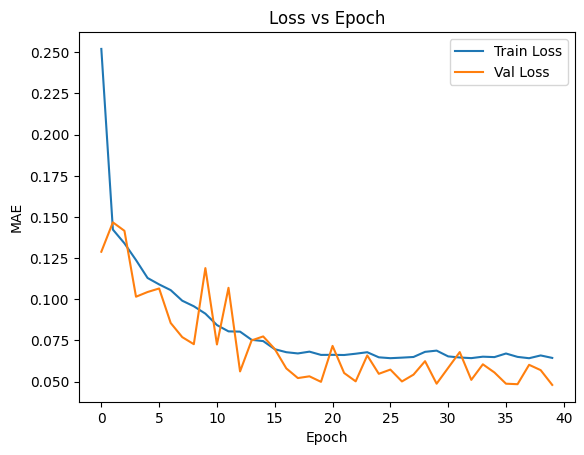

In [64]:
plt.plot(history_tlkm.history['loss'], label='Train Loss')
plt.plot(history_tlkm.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [65]:
y_pred_tlkm = model_tlkm.predict(X_test_tlkm[..., np.newaxis]).flatten()
scaler_tlkm = scalers['TLKM']
y_pred_unscaled_tlkm = scaler_tlkm.inverse_transform(y_pred_tlkm.reshape(-1, 1)).flatten()
y_test_unscaled_tlkm = scaler_tlkm.inverse_transform(y_test_tlkm.reshape(-1, 1)).flatten()

mae_tlkm = mean_absolute_error(y_test_unscaled_tlkm, y_pred_unscaled_tlkm)
rmse_tlkm = np.sqrt(mean_squared_error(y_test_unscaled_tlkm, y_pred_unscaled_tlkm))
mape_tlkm = mean_absolute_percentage_error(y_test_unscaled_tlkm, y_pred_unscaled_tlkm) * 100

print('MAE Data Test TLKM : ', mae_tlkm)
print('RMSE Data Test TLKM: ', rmse_tlkm)
print('MAPE Data Test TLKM: ', mape_tlkm)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
MAE Data Test TLKM :  29.629880990555037
RMSE Data Test TLKM:  47.276579479519945
MAPE Data Test TLKM:  1.074212934913925


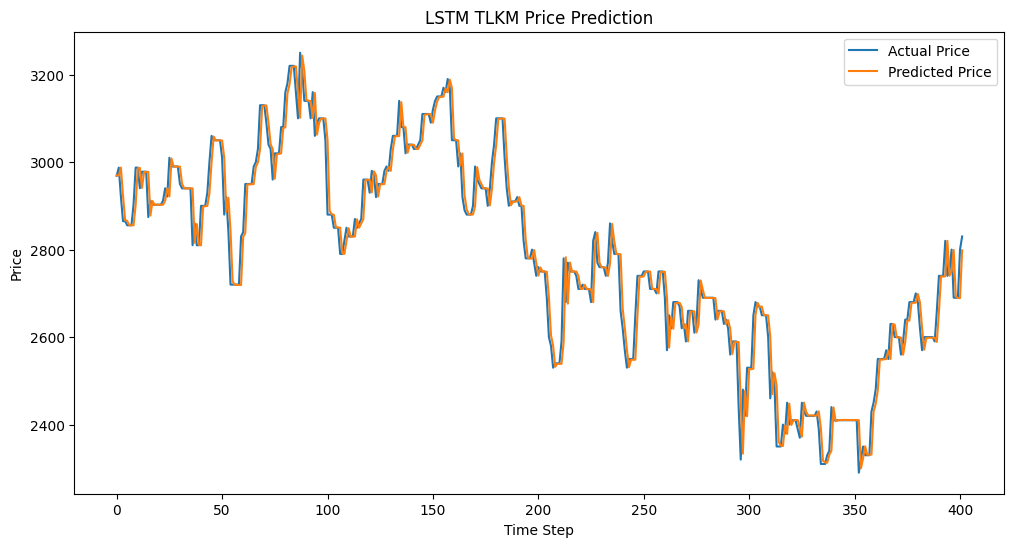

In [66]:
plt.figure(figsize=(12,6))
plt.plot(y_test_unscaled_tlkm, label='Actual Price')
plt.plot(y_pred_unscaled_tlkm, label='Predicted Price')
plt.title('LSTM TLKM Price Prediction')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.show()

In [67]:
time_span = {'1d': 1, '1w': 7, '1m': 30, '3m': 90, '6m': 180}
recent_data_tlkm = data_tlkm[-365:]

pred_dict_tlkm = {}
for label, steps in time_span.items():
    X = recent_data_tlkm.copy()
    for _ in range(steps):
        x_input = X[-365:].reshape(1, 365, 1)
        next_pred = model_tlkm.predict(x_input, verbose=0)[0, 0]
        X = np.append(X, next_pred)

    # Ambil nilai terakhir dan kembalikan ke skala asli
    unscaled_pred_tlkm = scaler_tlkm.inverse_transform([[X[-1]]])[0, 0]
    pred_dict_tlkm[label] = float(unscaled_pred_tlkm)

pred_dict_tlkm

{'1d': 2827.8563676980043,
 '1w': 2819.365036343455,
 '1m': 2788.2261925661296,
 '3m': 2702.418543882152,
 '6m': 2557.3405867943475}

## ASII

In [68]:
window_size = 30
horizon = 1

data_asii = df_scaled['ASII'].values
X_train_asii, y_train_asii, X_val_asii, y_val_asii, X_test_asii, y_test_asii = split_data(data_asii, window_size, horizon)

model_asii = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1)
])

model_asii.compile(optimizer='adam', loss='mae', metrics=['mape'])

model_asii.summary()
print("Model input shape:", model_asii.input_shape)
print("Model output shape:", model_asii.output_shape)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Model input shape: (None, 30, 1)
Model output shape: (None, 1)


In [69]:
history_asii = model_asii.fit(X_train_asii[..., np.newaxis], y_train_asii,
              validation_data=(X_val_asii[..., np.newaxis], y_val_asii),
              epochs=40)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.3633 - mape: 94.7456 - val_loss: 0.1196 - val_mape: 88.7595
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1563 - mape: 68.6746 - val_loss: 0.1136 - val_mape: 72.4558
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1442 - mape: 70.9182 - val_loss: 0.1005 - val_mape: 70.4004
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1320 - mape: 54.5447 - val_loss: 0.0932 - val_mape: 59.9370
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1274 - mape: 56.4887 - val_loss: 0.0972 - val_mape: 55.8675
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1223 - mape: 47.9787 - val_loss: 0.1258 - val_mape: 55.1977
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1149 - mape: 46.7453 - val_loss: 0.0871 - val_mape: 48.6779
Epoch 8/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1061 - mape: 49.3912 - val_loss: 0.0789 - val_mape: 51.2312
Epoch 9/40
59/59 ━━━━━━━━━━━━━━━

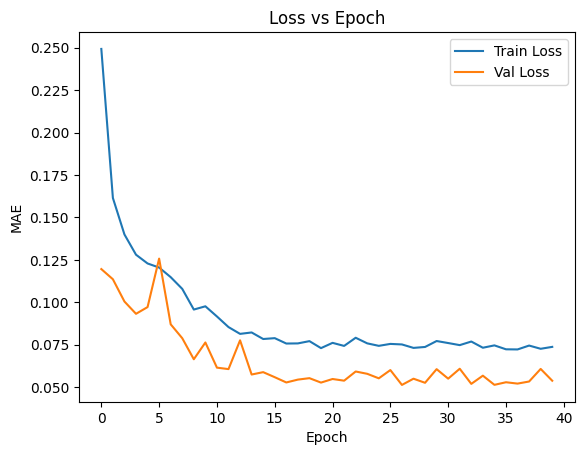

In [70]:
plt.plot(history_asii.history['loss'], label='Train Loss')
plt.plot(history_asii.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [71]:
y_pred_asii = model_asii.predict(X_test_asii[..., np.newaxis]).flatten()
scaler_asii = scalers['ASII']
y_pred_unscaled_asii = scaler_asii.inverse_transform(y_pred_asii.reshape(-1, 1)).flatten()
y_test_unscaled_asii = scaler_asii.inverse_transform(y_test_asii.reshape(-1, 1)).flatten()

mae_asii = mean_absolute_error(y_test_unscaled_asii, y_pred_unscaled_asii)
rmse_asii = np.sqrt(mean_squared_error(y_test_unscaled_asii, y_pred_unscaled_asii))
mape_asii = mean_absolute_percentage_error(y_test_unscaled_asii, y_pred_unscaled_asii) * 100

print('MAE Data Test ASII : ', mae_asii)
print('RMSE Data Test ASII: ', rmse_asii)
print('MAPE Data Test ASII: ', mape_asii)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
MAE Data Test ASII :  39.251783076803484
RMSE Data Test ASII:  63.47369718963835
MAPE Data Test ASII:  0.8780554573593908


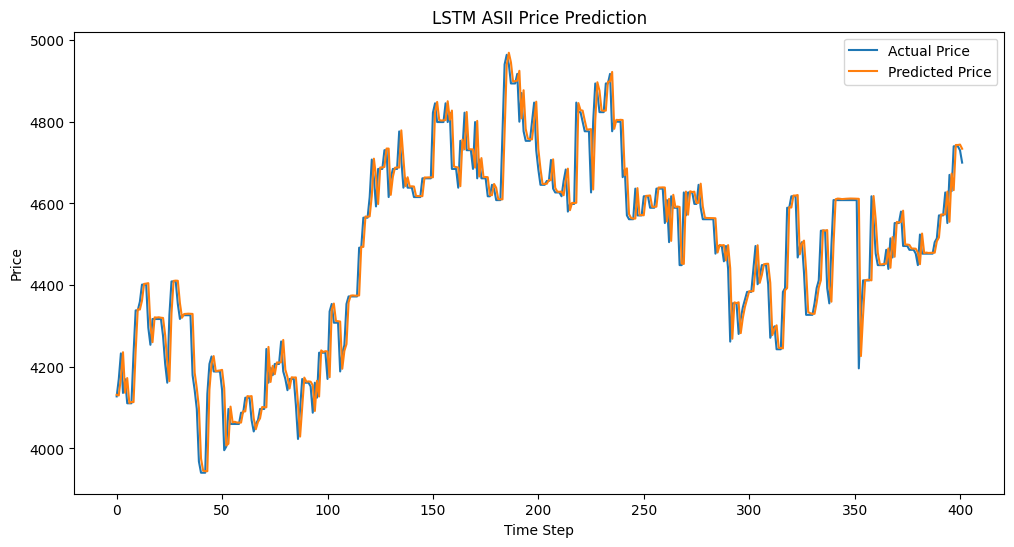

In [72]:
plt.figure(figsize=(12,6))
plt.plot(y_test_unscaled_asii, label='Actual Price')
plt.plot(y_pred_unscaled_asii, label='Predicted Price')
plt.title('LSTM ASII Price Prediction')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.show()

In [73]:
time_span = {'1d': 1, '1w': 7, '1m': 30, '3m': 90, '6m': 180}
recent_data_asii = data_asii[-365:]

pred_dict_asii = {}
for label, steps in time_span.items():
    X = recent_data_asii.copy()
    for _ in range(steps):
        x_input = X[-365:].reshape(1, 365, 1)
        next_pred = model_asii.predict(x_input, verbose=0)[0, 0]
        X = np.append(X, next_pred)

    # Ambil nilai terakhir dan kembalikan ke skala asli
    unscaled_pred_asii = scaler_asii.inverse_transform([[X[-1]]])[0, 0]
    pred_dict_asii[label] = float(unscaled_pred_asii)

pred_dict_asii

{'1d': 4704.501950542589,
 '1w': 4729.4148183460275,
 '1m': 4809.327543784537,
 '3m': 5105.810444035703,
 '6m': 5760.850424549519}

## BBNI

In [74]:
window_size = 30
horizon = 1

data_bbni = df_scaled['BBNI'].values
X_train_bbni, y_train_bbni, X_val_bbni, y_val_bbni, X_test_bbni, y_test_bbni = split_data(data_bbni, window_size, horizon)

model_bbni = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1)
])

model_bbni.compile(optimizer='adam', loss='mae', metrics=['mape'])

model_bbni.summary()
print("Model input shape:", model_bbni.input_shape)
print("Model output shape:", model_bbni.output_shape)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Model input shape: (None, 30, 1)
Model output shape: (None, 1)


In [75]:
history_bbni = model_bbni.fit(X_train_bbni[..., np.newaxis], y_train_bbni,
              validation_data=(X_val_bbni[..., np.newaxis], y_val_bbni),
              epochs=40)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.2643 - mape: 169.4196 - val_loss: 0.3556 - val_mape: 26.5329
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0895 - mape: 117.2326 - val_loss: 0.2228 - val_mape: 15.9562
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0878 - mape: 102.5744 - val_loss: 0.2207 - val_mape: 16.1127
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0730 - mape: 113.3812 - val_loss: 0.2250 - val_mape: 16.5245
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0779 - mape: 164.2597 - val_loss: 0.1610 - val_mape: 11.6093
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0701 - mape: 148.5971 - val_loss: 0.2154 - val_mape: 16.2205
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0656 - mape: 119.1847 - val_loss: 0.1752 - val_mape: 13.0318
Epoch 8/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0616 - mape: 58.0741 - val_loss: 0.1260 - val_mape: 9.2524
Epoch 9/40
59/59 ━━━━━━━━━

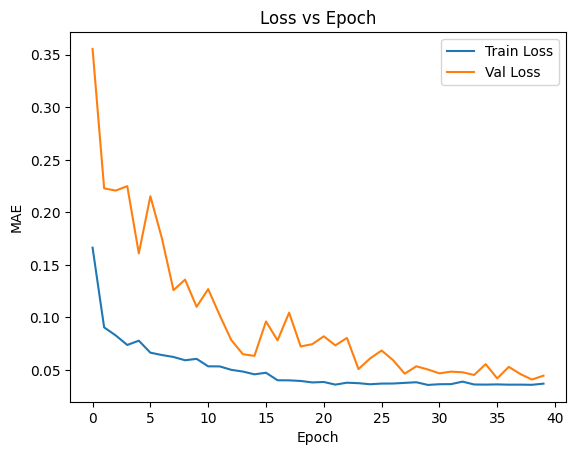

In [76]:
plt.plot(history_bbni.history['loss'], label='Train Loss')
plt.plot(history_bbni.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [77]:
y_pred_bbni = model_bbni.predict(X_test_bbni[..., np.newaxis]).flatten()
scaler_bbni = scalers['BBNI']
y_pred_unscaled_bbni = scaler_bbni.inverse_transform(y_pred_bbni.reshape(-1, 1)).flatten()
y_test_unscaled_bbni = scaler_bbni.inverse_transform(y_test_bbni.reshape(-1, 1)).flatten()

mae_bbni = mean_absolute_error(y_test_unscaled_bbni, y_pred_unscaled_bbni)
rmse_bbni = np.sqrt(mean_squared_error(y_test_unscaled_bbni, y_pred_unscaled_bbni))
mape_bbni = mean_absolute_percentage_error(y_test_unscaled_bbni, y_pred_unscaled_bbni) * 100

print('MAE Data Test BBNI : ', mae_bbni)
print('RMSE Data Test BBNI: ', rmse_bbni)
print('MAPE Data Test BBNI: ', mape_bbni)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
MAE Data Test BBNI :  60.77307918415734
RMSE Data Test BBNI:  88.5065567476703
MAPE Data Test BBNI:  1.3754061162840774


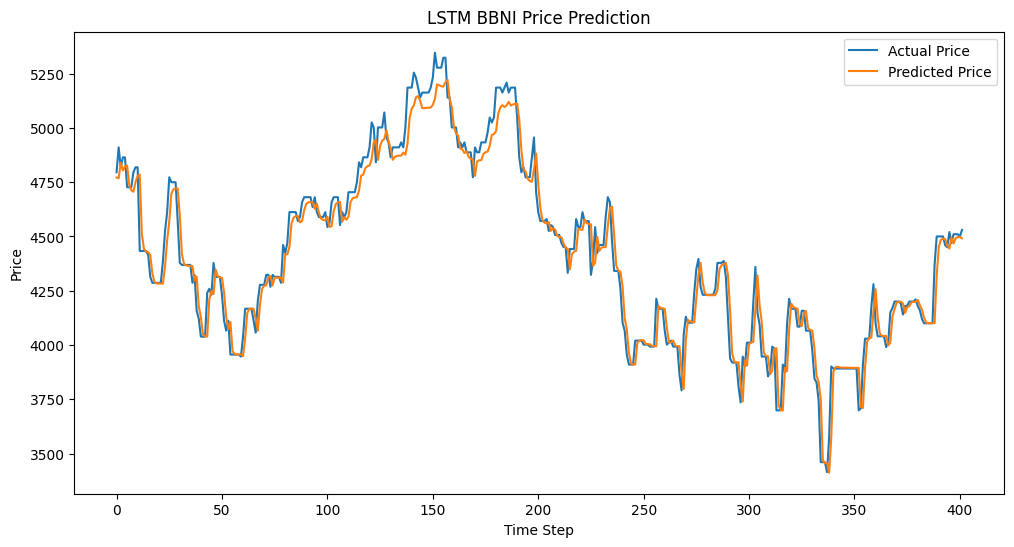

In [78]:
plt.figure(figsize=(12,6))
plt.plot(y_test_unscaled_bbni, label='Actual Price')
plt.plot(y_pred_unscaled_bbni, label='Predicted Price')
plt.title('LSTM BBNI Price Prediction')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.show()

In [79]:
time_span = {'1d': 1, '1w': 7, '1m': 30, '3m': 90, '6m': 180}
recent_data_bbni = data_bbni[-365:]

pred_dict_bbni = {}
for label, steps in time_span.items():
    X = recent_data_bbni.copy()
    for _ in range(steps):
        x_input = X[-365:].reshape(1, 365, 1)
        next_pred = model_bbni.predict(x_input, verbose=0)[0, 0]
        X = np.append(X, next_pred)

    # Ambil nilai terakhir dan kembalikan ke skala asli
    unscaled_pred_bbni = scaler_bbni.inverse_transform([[X[-1]]])[0, 0]
    pred_dict_bbni[label] = float(unscaled_pred_bbni)

pred_dict_bbni

{'1d': 4511.155260803012,
 '1w': 4460.093475993474,
 '1m': 4328.096937913191,
 '3m': 4185.435366560974,
 '6m': 4129.953372993821}

## ICBP

In [80]:
window_size = 30
horizon = 1

data_icbp = df_scaled['ICBP'].values
X_train_icbp, y_train_icbp, X_val_icbp, y_val_icbp, X_test_icbp, y_test_icbp = split_data(data_icbp, window_size, horizon)

model_icbp = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1)
])

model_icbp.compile(optimizer='adam', loss='mae', metrics=['mape'])

model_icbp.summary()
print("Model input shape:", model_icbp.input_shape)
print("Model output shape:", model_icbp.output_shape)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Model input shape: (None, 30, 1)
Model output shape: (None, 1)


In [81]:
history_icbp = model_icbp.fit(X_train_icbp[..., np.newaxis], y_train_icbp,
              validation_data=(X_val_icbp[..., np.newaxis], y_val_icbp),
              epochs=40)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.3076 - mape: 82.7430 - val_loss: 0.1905 - val_mape: 21.5177
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1118 - mape: 60.8834 - val_loss: 0.1528 - val_mape: 18.2939
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0987 - mape: 72.6299 - val_loss: 0.1352 - val_mape: 16.4887
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1013 - mape: 50.0732 - val_loss: 0.1099 - val_mape: 15.1266
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0843 - mape: 36.6755 - val_loss: 0.1086 - val_mape: 15.5707
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0820 - mape: 42.4583 - val_loss: 0.1044 - val_mape: 14.5325
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0771 - mape: 46.8213 - val_loss: 0.1106 - val_mape: 16.0885
Epoch 8/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0754 - mape: 38.8417 - val_loss: 0.1026 - val_mape: 15.7420
Epoch 9/40
59/59 ━━━━━━━━━━━━━━━

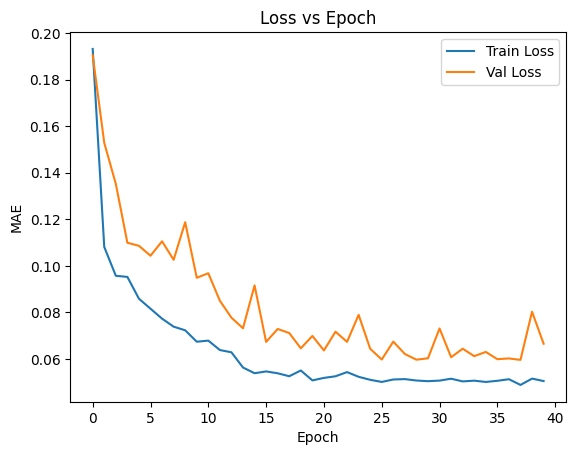

In [82]:
plt.plot(history_icbp.history['loss'], label='Train Loss')
plt.plot(history_icbp.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [83]:
y_pred_icbp = model_icbp.predict(X_test_icbp[..., np.newaxis]).flatten()
scaler_icbp = scalers['ICBP']
y_pred_unscaled_icbp = scaler_icbp.inverse_transform(y_pred_icbp.reshape(-1, 1)).flatten()
y_test_unscaled_icbp = scaler_icbp.inverse_transform(y_test_icbp.reshape(-1, 1)).flatten()

mae_icbp = mean_absolute_error(y_test_unscaled_icbp, y_pred_unscaled_icbp)
rmse_icbp = np.sqrt(mean_squared_error(y_test_unscaled_icbp, y_pred_unscaled_icbp))
mape_icbp = mean_absolute_percentage_error(y_test_unscaled_icbp, y_pred_unscaled_icbp) * 100

print('MAE Data Test ICBP : ', mae_icbp)
print('RMSE Data Test ICBP: ', rmse_icbp)
print('MAPE Data Test ICBP: ', mape_icbp)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
MAE Data Test ICBP :  125.0796092778296
RMSE Data Test ICBP:  175.59733644635435
MAPE Data Test ICBP:  1.1138481637669504


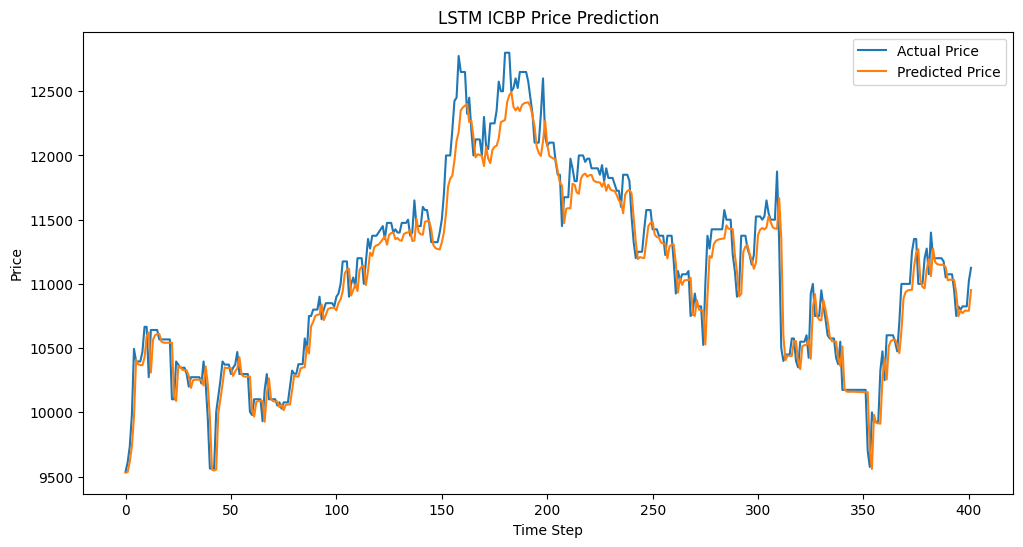

In [84]:
plt.figure(figsize=(12,6))
plt.plot(y_test_unscaled_icbp, label='Actual Price')
plt.plot(y_pred_unscaled_icbp, label='Predicted Price')
plt.title('LSTM ICBP Price Prediction')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.show()

In [85]:
time_span = {'1d': 1, '1w': 7, '1m': 30, '3m': 90, '6m': 180}
recent_data_icbp = data_icbp[-365:]

pred_dict_icbp = {}
for label, steps in time_span.items():
    X = recent_data_icbp.copy()
    for _ in range(steps):
        x_input = X[-365:].reshape(1, 365, 1)
        next_pred = model_icbp.predict(x_input, verbose=0)[0, 0]
        X = np.append(X, next_pred)

    # Ambil nilai terakhir dan kembalikan ke skala asli
    unscaled_pred_icbp = scaler_icbp.inverse_transform([[X[-1]]])[0, 0]
    pred_dict_icbp[label] = float(unscaled_pred_icbp)

pred_dict_icbp

{'1d': 11046.569777317785,
 '1w': 10831.273512387397,
 '1m': 10288.210247751686,
 '3m': 9529.22857956083,
 '6m': 9085.739164603716}

## All at once

In [87]:
models = {}
history = {}
window_size = 30
horizon = 1

for ticker in tickers:
    print(f"Training model for {ticker}...")

    data = df_scaled[ticker].values
    X_train, y_train, X_val, y_val, X_test, y_test = split_data(data, window_size, horizon)

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
        LSTM(32),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mae', metrics=['mape'])
    h = model.fit(X_train[..., np.newaxis], y_train,
                  validation_data=(X_val[..., np.newaxis], y_val),
                  epochs=40)

    models[ticker] = model
    history[ticker] = h.history

Training model for BBCA...
Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.2331 - mape: 76.7799 - val_loss: 0.1489 - val_mape: 12.7508
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0602 - mape: 48.0780 - val_loss: 0.0871 - val_mape: 7.5060
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0505 - mape: 36.1308 - val_loss: 0.0983 - val_mape: 8.5094
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0493 - mape: 33.1787 - val_loss: 0.1018 - val_mape: 8.8058
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0468 - mape: 44.1418 - val_loss: 0.0815 - val_mape: 7.0918
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0440 - mape: 31.3419 - val_loss: 0.0906 - val_mape: 7.9015
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0452 - mape: 35.1742 - val_loss: 0.0621 - val_mape: 5.5001
Epoch 8/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0396 - mape: 23.0419 - val_loss: 0.1119 - val_mape: 9.8471
Epoch 9/40
5

In [ ]:
results = {}

for ticker in tickers:
    print(f"Evaluating model for {ticker}")
    model = models[ticker]
    data = df_scaled[ticker].values
    _, _, _, _, X_test, y_test = split_data(data, window_size, horizon)
    y_pred = model.predict(X_test[..., np.newaxis]).flatten()

    # Unscale hasil prediksi dan aktual
    scaler = scalers[ticker]
    y_pred_unscaled = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(y_test_unscaled, y_pred_unscaled)
    rmse = np.sqrt(mean_squared_error(y_test_unscaled, y_pred_unscaled))
    mape = mean_absolute_percentage_error(y_test_unscaled, y_pred_unscaled) * 100

    results[ticker] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

pd.DataFrame(results).T

Evaluating model for BBCA
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Evaluating model for BYAN
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Evaluating model for TPIA
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Evaluating model for BBRI
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Evaluating model for BMRI
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
Evaluating model for DSSA
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
Evaluating model for TLKM
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Evaluating model for ASII
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Evaluating model for BBNI
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Evaluating model for ICBP
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


,MAE,RMSE,MAPE
BBCA,164.622272,199.671520,1.723685
BYAN,388.668639,488.557411,2.093574
TPIA,2738.204640,2894.910078,32.364309
BBRI,50.652966,75.413704,1.235648
BMRI,190.816073,239.426263,3.252560
DSSA,12186.344554,13717.262126,31.014842
TLKM,30.244482,47.226597,1.097131
ASII,39.557342,63.211657,0.886017
BBNI,82.093864,107.496748,1.820741
ICBP,119.396045,172.194786,1.063504


In [ ]:
futures = {'1d': 1, '1w': 7, '1m': 30, '3m': 90, '6m': 180}
predictions = {}

for ticker in tickers:
    print(f"Inferencing for {ticker}...")
    model = models[ticker]
    data = df_scaled[ticker].values
    recent_data = data[-window_size:]

    pred_dict = {}
    for label, steps in futures.items():
        X = recent_data.copy()
        for _ in range(steps):
            x_input = X[-window_size:].reshape(1, window_size, 1)
            next_pred = model.predict(x_input, verbose=0)[0, 0]
            X = np.append(X, next_pred)

        # Ambil nilai terakhir dan kembalikan ke skala asli
        unscaled_pred = scalers[ticker].inverse_transform([[X[-1]]])[0, 0]
        pred_dict[label] = unscaled_pred

    predictions[ticker] = pred_dict

pd.DataFrame(predictions)

Inferencing for BBCA...
Inferencing for BYAN...
Inferencing for TPIA...
Inferencing for BBRI...
Inferencing for BMRI...
Inferencing for DSSA...
Inferencing for TLKM...
Inferencing for ASII...
Inferencing for BBNI...
Inferencing for ICBP...


,BBCA,BYAN,TPIA,BBRI,BMRI,DSSA,TLKM,ASII,BBNI,ICBP
1d,9372.081243,19536.609107,5699.727659,4343.370216,5310.913658,26614.748343,2829.087375,4703.497309,4470.484972,11059.745705
1w,8958.543082,18886.150076,5357.189158,4264.687792,4951.371508,25743.654351,2833.605046,4722.968428,4291.226998,10901.767930
1m,8080.775097,18266.321070,3672.550642,4079.803476,4642.670004,16446.576450,2842.855833,4770.134692,3872.829064,10506.759613
3m,7508.981074,18304.850627,2536.641387,3897.400149,4570.441697,10832.105136,2857.930273,4873.247989,3561.717571,10009.272075
6m,7188.509392,18304.321018,2111.480230,3765.499441,4566.988394,8329.643970,2866.429347,4987.429309,3492.916379,9701.175391


# Save Model

In [88]:
import joblib
import os

models_dict = {
    'bbca': model_bbca,
    'byan': model_byan,
    'tpia': model_tpia,
    'bbri': model_bbri,
    'bmri': model_bmri,
    'dssa': model_dssa,
    'tlkm': model_tlkm,
    'asii': model_asii,
    'bbni': model_bbni,
    'icbp': model_icbp
}

# Simpan models
os.makedirs("models", exist_ok=True)
for name, model in models_dict.items():
    model.save(f'models/model_{name}.h5')

In [89]:
# Simpan scalers per emiten
os.makedirs("scalers", exist_ok=True)
for symbol, scaler in scalers.items():
    if symbol != 'Date':
        joblib.dump(scaler, f"scalers/{symbol}_scaler.pkl")